### Config

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from hydra import compose, initialize
from pathlib import Path
from omegaconf import OmegaConf

initialize(config_path="../config", version_base="1.3")
cfg = compose(config_name="config")
print(OmegaConf.to_yaml(cfg))

sys.path.insert(0, str(cfg.paths.project_root))

from src.phyid_decomposition import MultiPromptPhyID, PromptPhyID, PhyIDTimeSeries
from src.ranked_deactivation_analysis import RankedDeactivationAnalysis, RankedDeactivationResults


paths:
  project_root: /home/p84400019/projects/consciousness-llms/IT-LLMs/
  model_path: ${model.company}/${model.model_family}/${model.model_size}/${model.it}/
  activation_method: ${time_series.node_type}/${time_series.node_activation}/${time_series.projection_method}/
  phyid_method: ${paths.activation_method}phyid_tau-${phyid.tau}/phyid_kind-${phyid.kind}/phyid_redundancy-${phyid.redundancy}/
  deactivation_method: deactivate_k_nodes_per_iteration-${deactivation_analysis.deactivate_k_nodes_per_iteration}/max_deactivated_nodes-${deactivation_analysis.max_deactivated_nodes}/
  data_dir: ${paths.project_root}data/${paths.model_path}${generation.name}/
  data_activations_dir: ${paths.data_dir}activations/
  data_activations_file: ${paths.data_activations_dir}multi_prompt_activations.pkl
  data_phyid_dir: ${paths.data_dir}phyid/${paths.phyid_method}
  data_phyid_file: ${paths.data_phyid_dir}multi_prompt_phyid.pkl
  data_phyid_file_data_array: ${paths.data_phyid_dir}multi_prompt_phyid.n

/home/p84400019/miniconda3/envs/int/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Model and PhyID Decomposition

#### Load model and tokenizer

Load model with Flash Attention to Avoid Attention Caching

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model = AutoModelForCausalLM.from_pretrained(
    cfg.model.hf_name,
    torch_dtype=torch.float16,      # ★ key line ★
    device_map="auto",
    trust_remote_code=True,
)
# model.config._attn_implementation = "flash_attention_2"

tokenizer = AutoTokenizer.from_pretrained(
    cfg.model.hf_name,
    use_fast=True,
    trust_remote_code=True,
)

In [3]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb):

#### Load the PhyID decomposition

In [4]:
data_phyid_path = cfg.paths.data_phyid_dir

print(f"Loading phyid from {data_phyid_path}")
phyid = MultiPromptPhyID.load_average_prompt_phyid(dir_path=data_phyid_path)
# phyid = MultiPromptPhyID.load_average_prompt_phyid(dir_path='/home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/1B/base/base_prompt/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/')

Loading phyid from /home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/1B/base/original_prompts/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/
Average PromptPhyID loaded from /home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/1B/base/original_prompts/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/average.pkl


In [5]:
# phyid.compute_extra_atoms()
# file_path = data_phyid_path + "average.pkl"
# phyid.save(file_path)

In [6]:
import pickle
with open("/home/p84400019/projects/consciousness-llms/IT-LLMs/data/meta/llama-3/1B/base/original_prompts/phyid/attention/attention_outputs/norm/phyid_tau-1/phyid_kind-gaussian/phyid_redundancy-MMI/prompt_14.pkl", "rb") as f:
    prompt_phyid = pickle.load(f)
print(prompt_phyid.data_array)

None


In [7]:
print(prompt_phyid.phyid[(0,0,0,1)].sts.shape)

(127,)


In [8]:
print(phyid.phyid[(0,0,0,1)].sts.shape)
print(phyid.phyid[(0,0,0,1)].sts.dtype)
print(phyid.data_array)

(1,)
float16
None


In [9]:
import numpy as np
phyid.data_array = None
print(phyid.data_array)
phyid.build_data_array()
print(phyid.data_array['atom'])  # or self.data_array.coords['atom'] if available


None
<xarray.DataArray 'atom' (atom: 16)> Size: 256B
array(['rtr', 'rts', 'rtx', 'rty', 'str_', 'sts', 'stx', 'sty', 'xtr', 'xts',
       'xtx', 'xty', 'ytr', 'yts', 'ytx', 'yty'], dtype='<U4')
Coordinates:
  * atom     (atom) <U4 256B 'rtr' 'rts' 'rtx' 'rty' ... 'ytr' 'yts' 'ytx' 'yty'


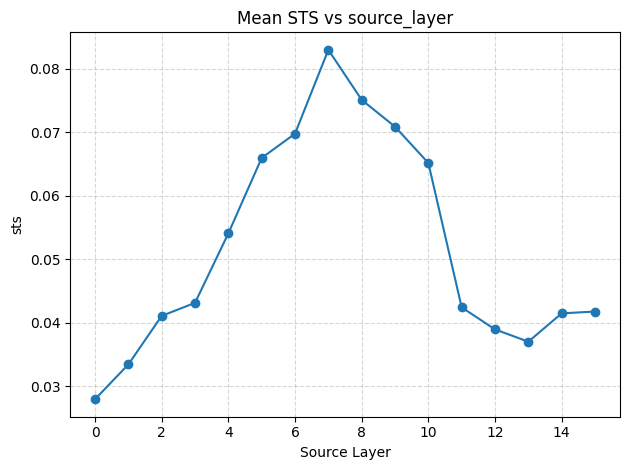

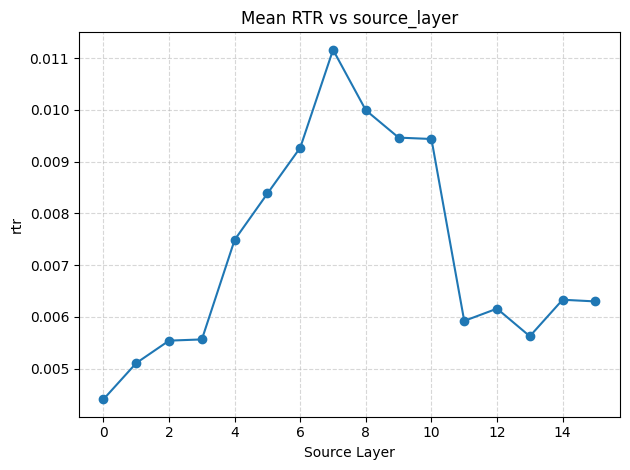

In [10]:
phyid.plot_mean_along('sts', 'source_layer')
phyid.plot_mean_along('rtr', 'source_layer')

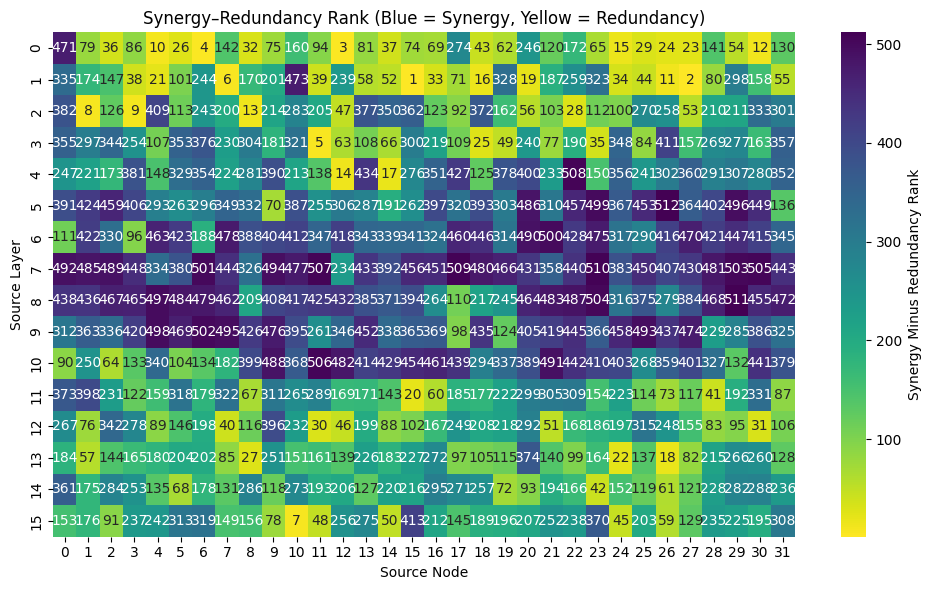

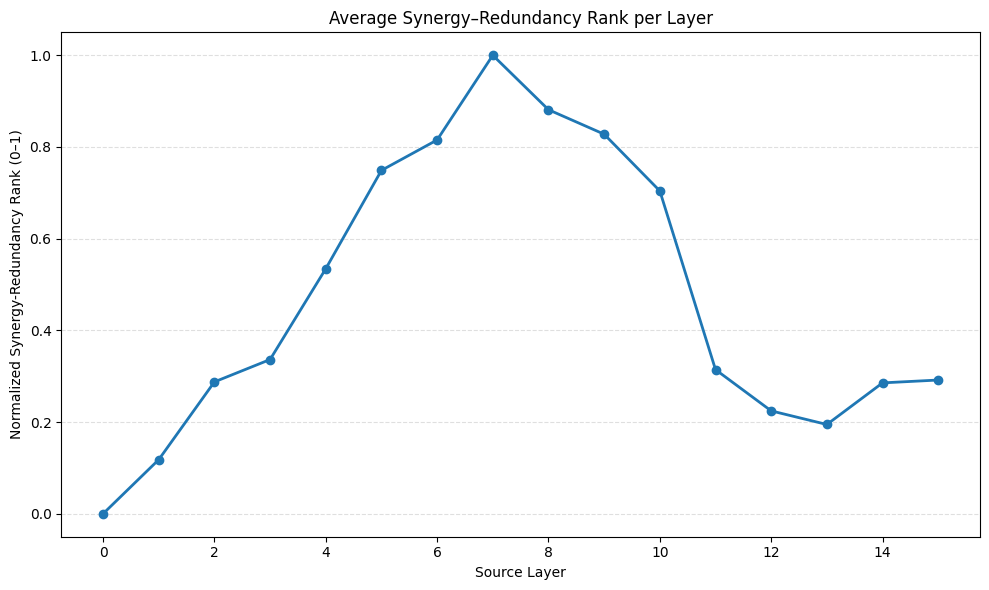

Synergy–Redundancy Rank of N03-L08: 465


In [11]:
phyid.__dict__.pop("syn_minus_red_rank", None)
node_ranking = phyid.syn_minus_red_rank
phyid.plot_syn_minus_red_rank_per_node(node_ranking)
phyid.plot_syn_minus_red_rank_per_layer(node_ranking)
print(f"Synergy–Redundancy Rank of N03-L08: {node_ranking.sel(source_node=3, source_layer=8).values}")

### Deactivation Analysis

In [12]:
deactivation = RankedDeactivationAnalysis(
    model=model,
    tokenizer=tokenizer,
    prompts=OmegaConf.to_container(cfg.generation.prompts, resolve=True),
    chat_template=cfg.model.apply_chat_template,
    node_ranking=node_ranking,
    max_new_tokens=cfg.generation.max_new_tokens,
)

In [13]:
results = deactivation.run(
    deactivate_k_nodes_per_iteration=cfg.deactivation_analysis.deactivate_k_nodes_per_iteration,
    max_deactivated_nodes=cfg.deactivation_analysis.max_deactivated_nodes,
    micro_batch_size=100,
    save_file_path=cfg.paths.data_deactivation_file
)

Getting non-deactivated model results...
Processing micro‑batch 1 of 0 …


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
Self KL divergence: 0.000000
Starting deactivation analysis: 20 max nodes, 5 per iteration

Iteration 1: Deactivating 0 nodes
Sample deactivated nodes: []
Getting deactivated model results for 0 deactivated nodes...
Processing teacher forcing micro-batch 1 of 1 …
Original tokens shape: torch.Size([160])
Original probs shape:  torch.Size([128, 128256])
Inferred prompt_len:   32
Start index: 31, End index: 159, Logits shape: torch.Size([160, 128256])
Generated text: Tags:
  you have 15 apples and you give away 5, how many do you have left?
15: 10.Arr: The you have __15 apples and you give away 5, how many do you have left?
 Answer judgment
Original tokens shape: torch.Size([160])
Original probs shape:  torch.Size([128, 128256])
Inferred prompt_len:   32
Start index: 31, End index: 159, Logits shape: torch.Size([160, 128256])
Generated text:  The is x Purpose/W w2 * = Pe

In [14]:
results = RankedDeactivationResults.load(file_path=cfg.paths.data_deactivation_file)
results.deactivation_results[0].divergence_per_category

<xarray.DataArray (category: 6)> Size: 24B
array([0.2591786 , 0.17367059, 0.19978622, 0.09735896, 0.02483632,
       0.00528399], dtype=float32)
Coordinates:
  * category  (category) <U21 504B 'simple_maths' ... 'social_cognition'

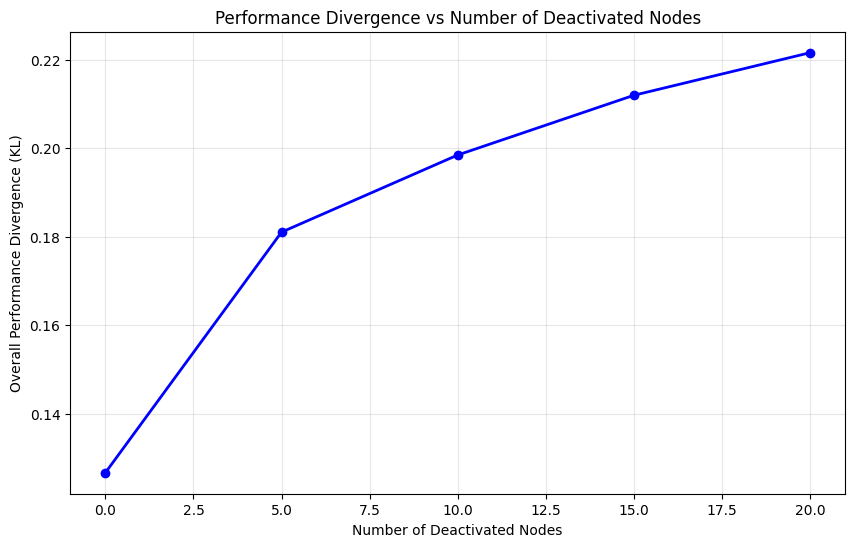

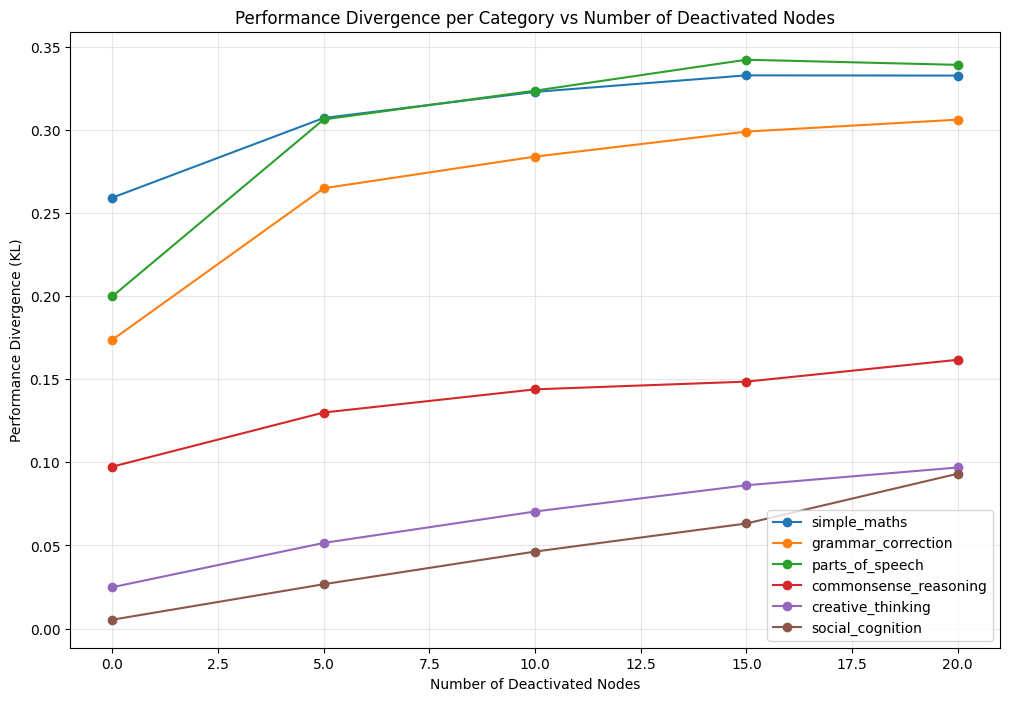

In [15]:
results.plot_overall_performance_divergence()
results.plot_performance_divergence_per_category()

In [16]:
# deactivation.plot_performance_divergence(results)

In [17]:
print(node_ranking.shape)
print(node_ranking.sel(source_node=3, source_layer=8).values)


(16, 32)
465


In [18]:
print(len(results['all']))
print(len(results['all'][0]))
print(results['all'][0][0].shape)
print(results['all'][0][1].shape)
print(results['all'][0][0])
print(results['all'][0][1])
print(results['all'][0][2])
for i in range(cfg.generation.max_new_tokens):
    assert results['all'][0][1][0].sum().item() - 1.0 < 1e-5, f"Probabilities do not sum to 1 at position {i}, got {results['all'][0][1][0].sum().item()}"
print("All probabilities sum to 1 for each token in the first sequence.")


TypeError: 'RankedDeactivationResults' object is not subscriptable